── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ purrr::%||%()   masks base::%||%()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.4.1 ──

✔ broom        1.0.12     ✔ rsample      1.3.2 
✔ dials        1.4.2      ✔ tailor       0.1.0 
✔ infer        1.1.0      ✔ tune         2.0.1 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.4.1      ✔ workflowsets 1.1.1 
✔ recipes      1.3.1      ✔ yardstick    1.3.2 

── Conflicts ───────────────────────────────────────── tidymodels_co

'data.frame':	1338 obs. of  6 variables:
 $ age     : int  19 18 28 33 32 31 46 37 37 60 ...
 $ bmi     : num  27.9 33.8 33 22.7 28.9 ...
 $ children: int  0 1 3 0 0 0 1 3 2 0 ...
 $ smoker  : num  1 0 0 0 0 0 0 0 0 0 ...
 $ gender  : num  1 0 0 0 0 1 1 1 0 1 ...
 $ charge  : num  16885 1726 4449 21984 3867 ...
1003 335

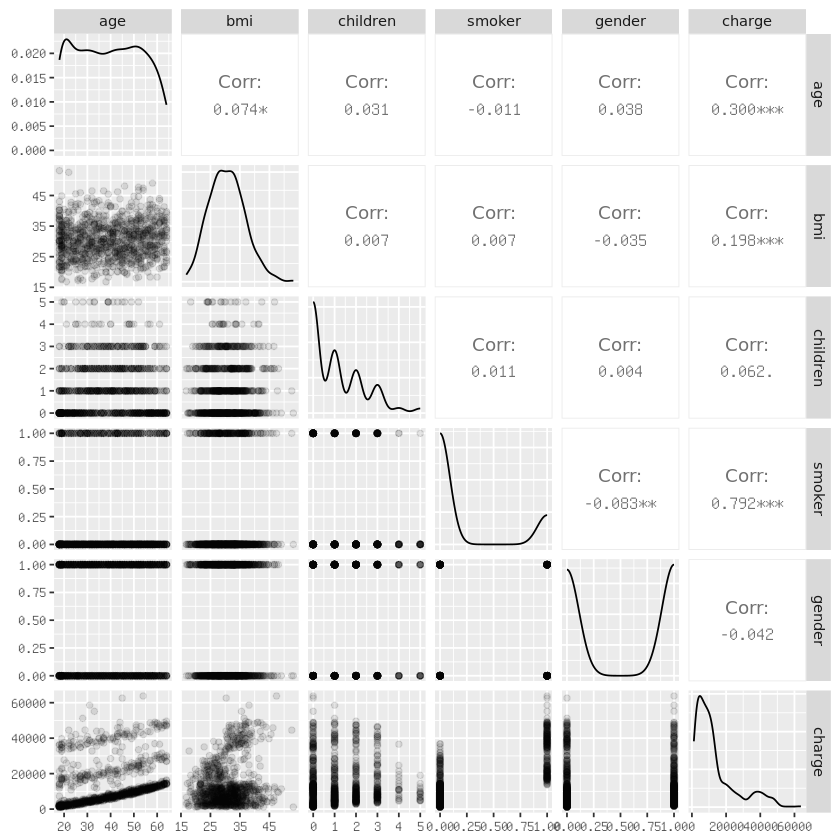

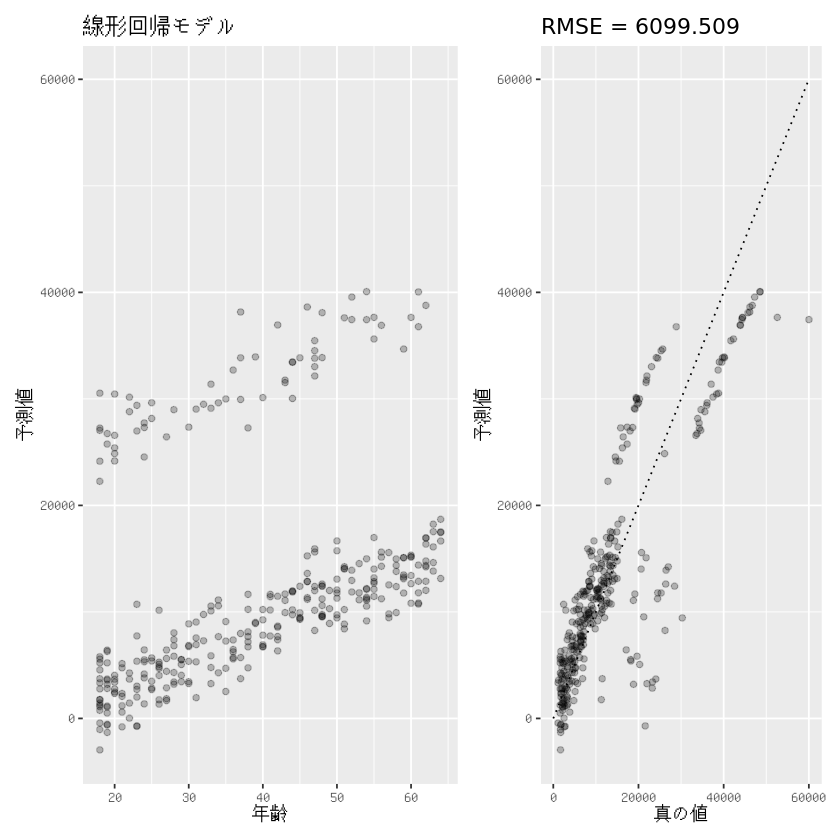

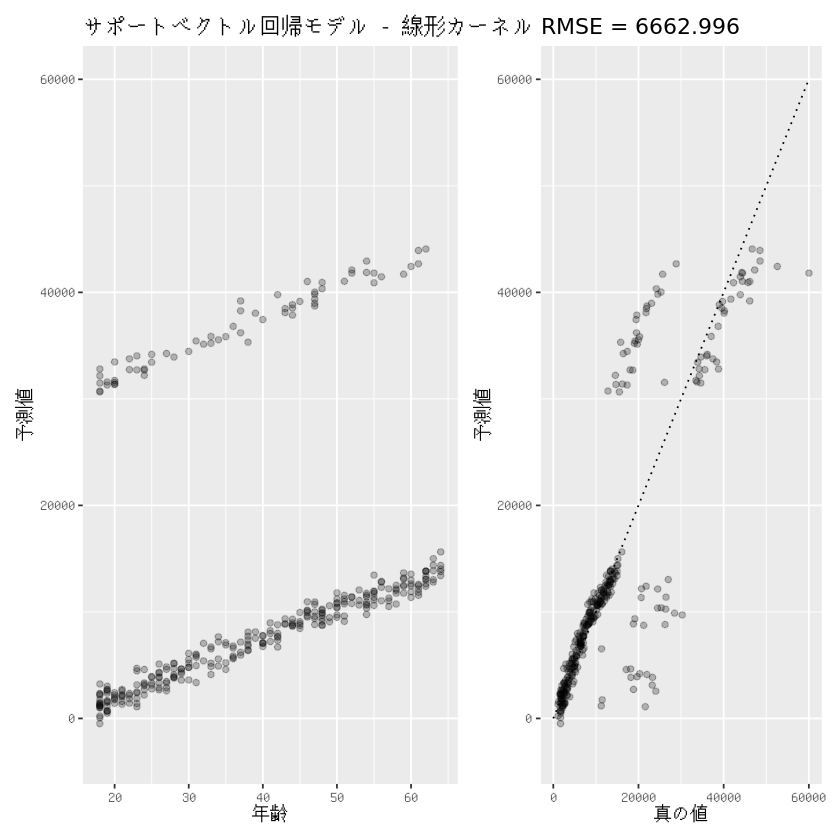

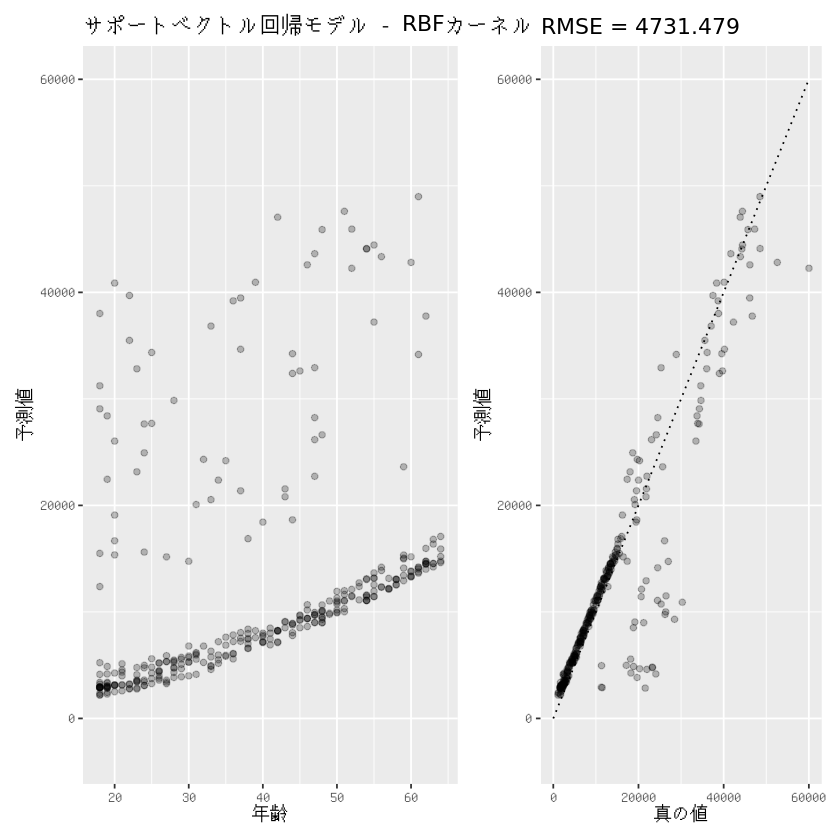

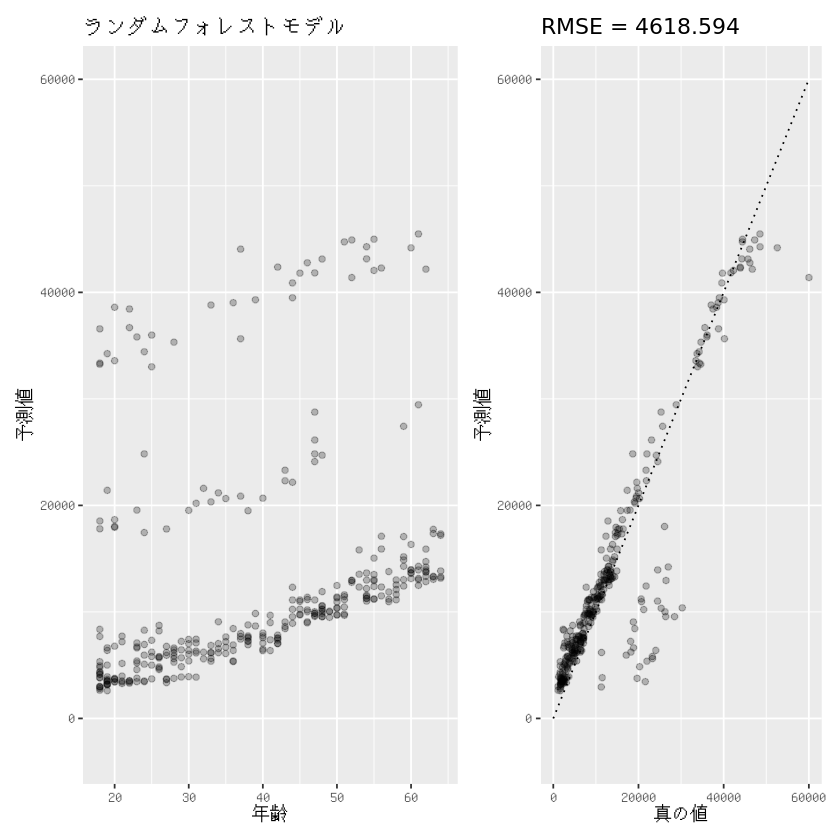

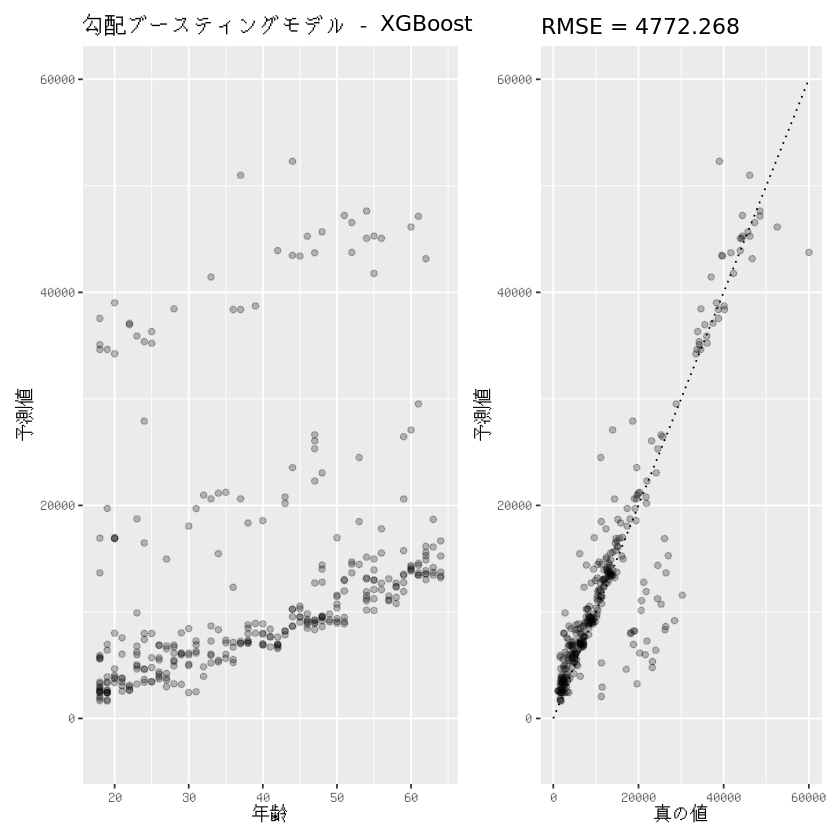

Preparation of a new explainer is initiated
  -> model label       :  model_fit  (  default  )
  -> data              :  335  rows  5  cols 
  -> target variable   :  335  values 
  -> predict function  :  yhat.model_fit  will be used (  default  )
  -> predicted values  :  No value for predict function target column. (  default  )
  -> model_info        :  package parsnip , ver. 1.4.1 , task regression (  default  ) 
  -> predicted values  :  numerical, min =  -2951.091 , mean =  12922.29 , max =  40069.9  
  -> residual function :  difference between y and yhat (  default  )
  -> residuals         :  numerical, min =  -11454.42 , mean =  188.611 , max =  22578.82  
  A new explainer has been created!  
Preparation of a new explainer is initiated
  -> model label       :  model_fit  (  default  )
  -> data              :  335  rows  5  cols 
  -> target variable   :  335  values 
  -> predict function  :  yhat.model_fit  will be used (  default  )
  -> predicted values  :  No value fo

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ingredients package.
  Please report the issue at
  <https://github.com/ModelOriented/ingredients/issues>.”


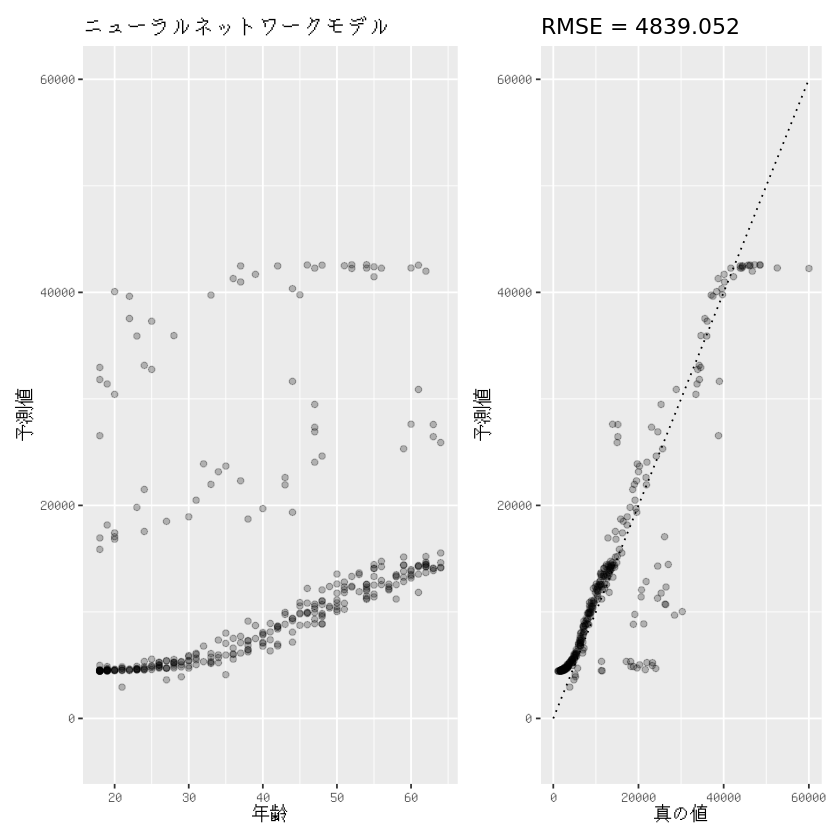

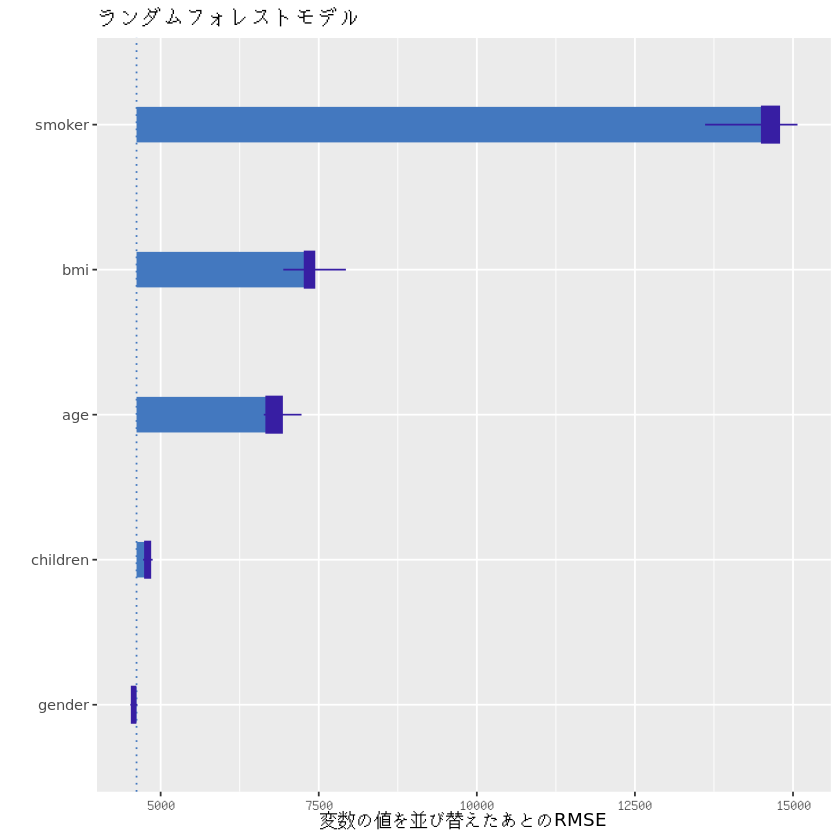

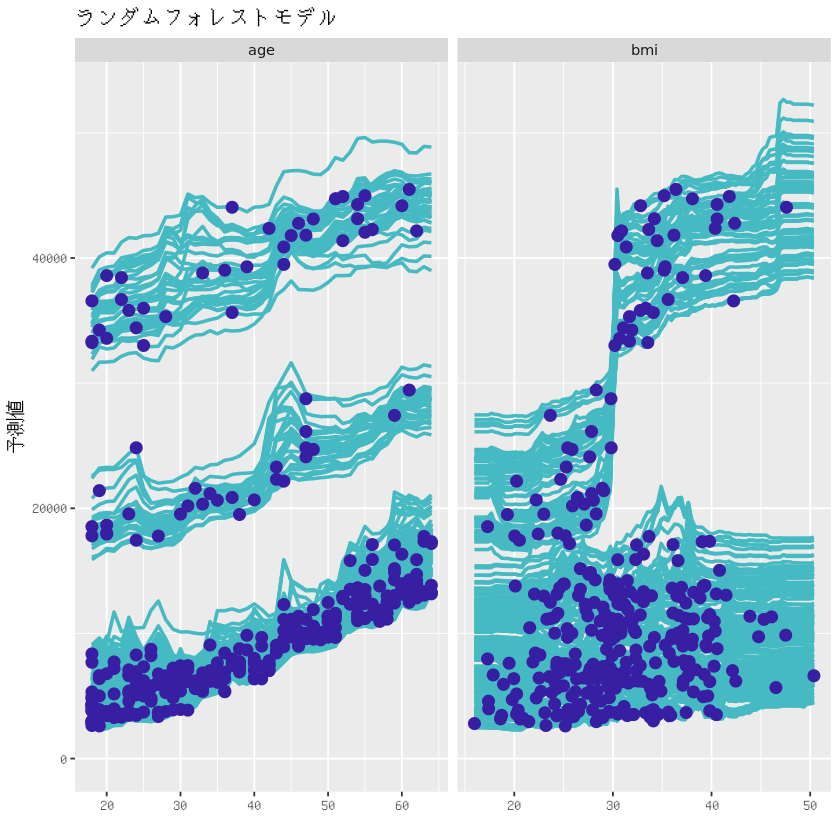

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ingredients package.
  Please report the issue at
  <https://github.com/ModelOriented/ingredients/issues>.”


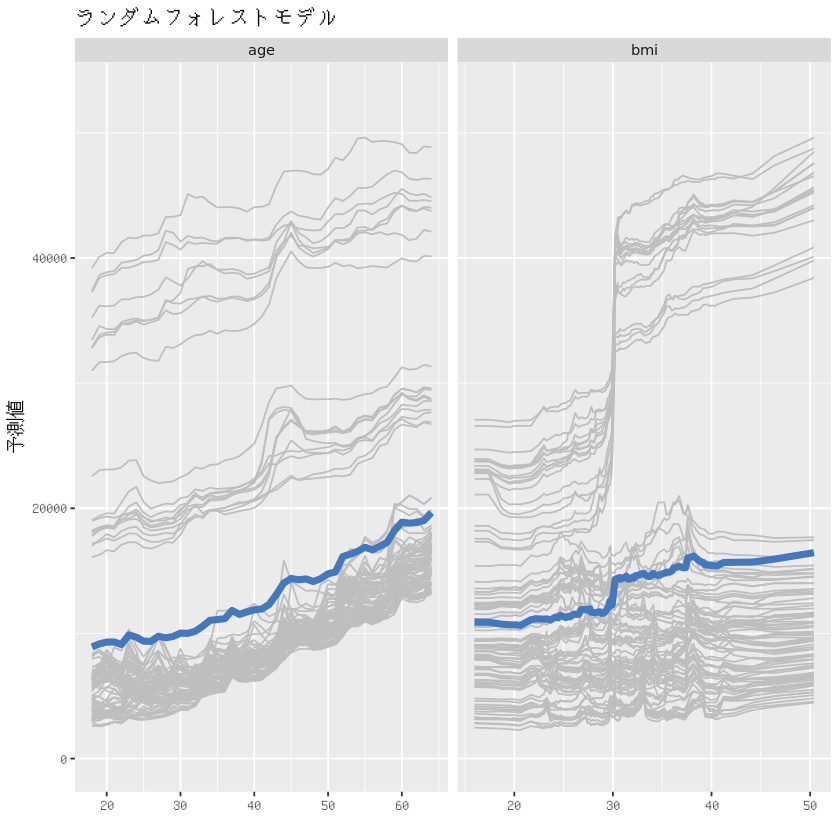

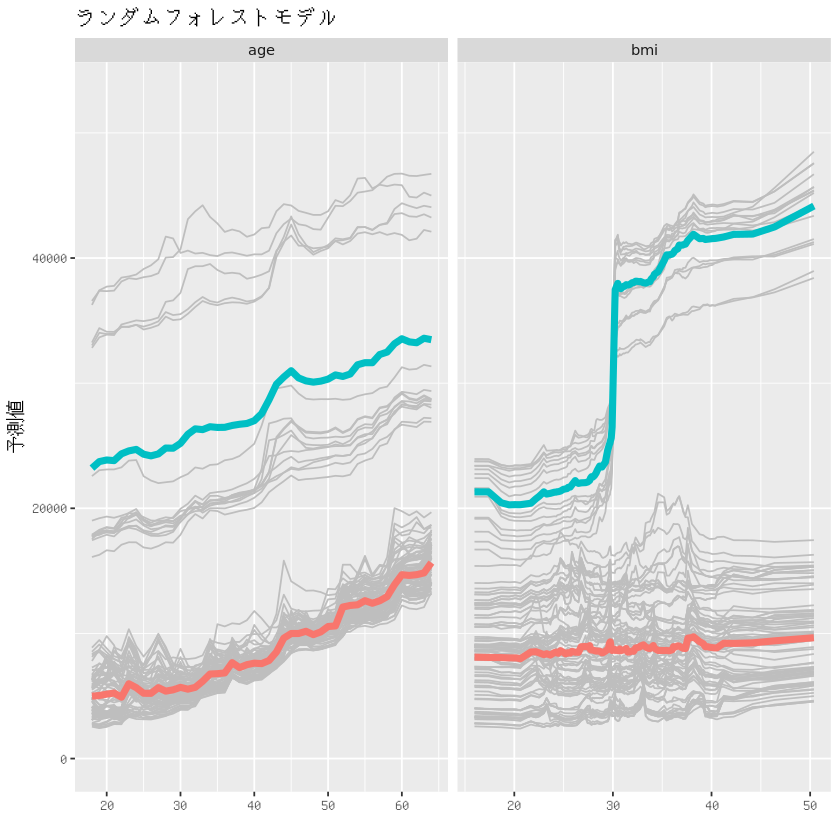

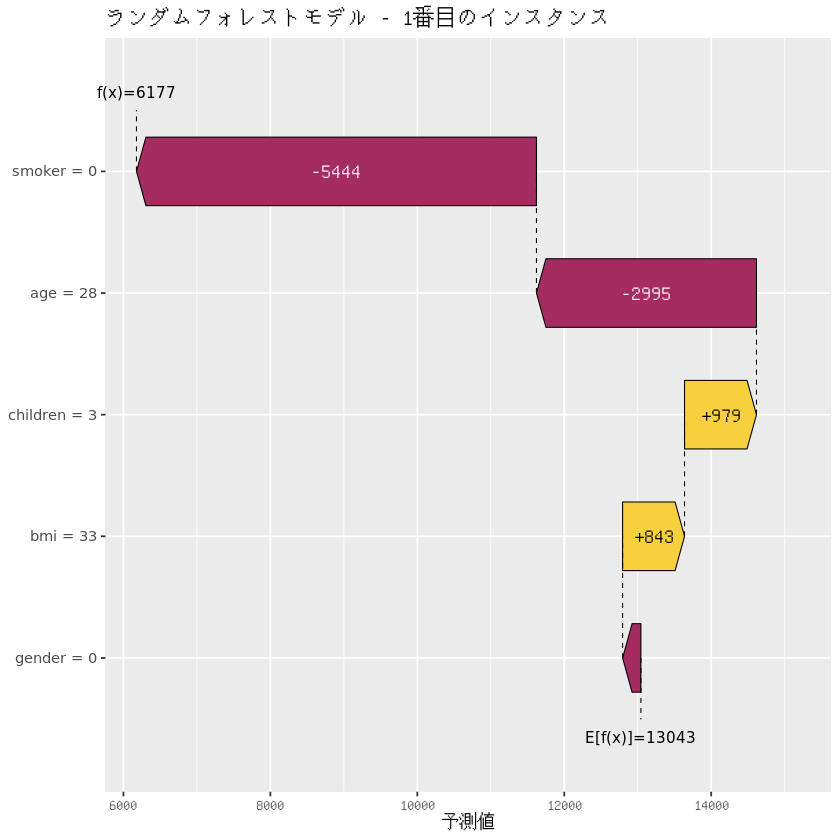

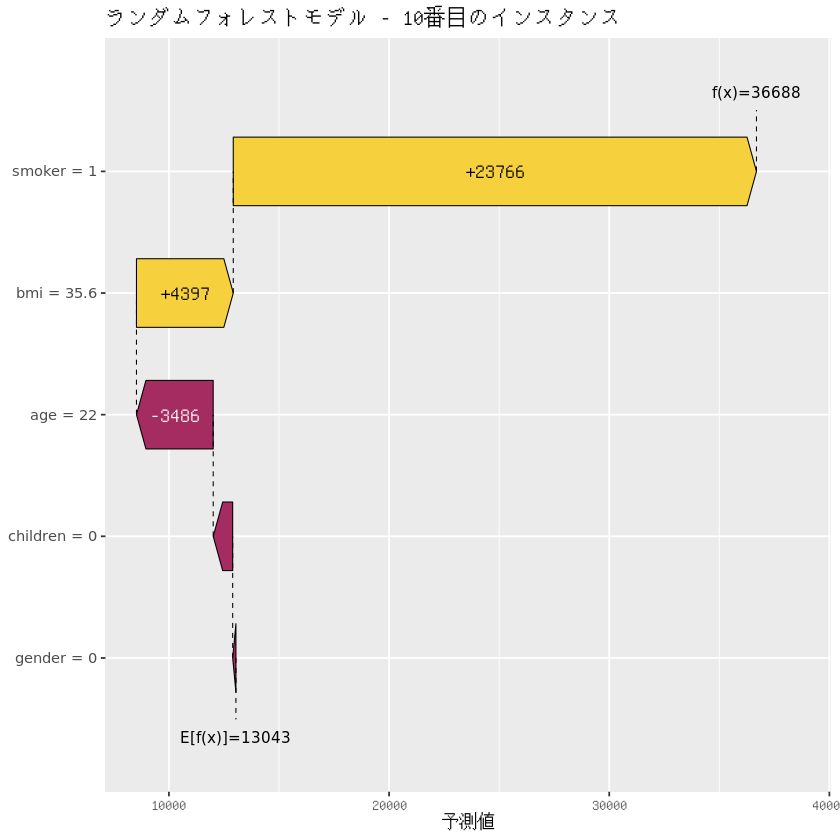

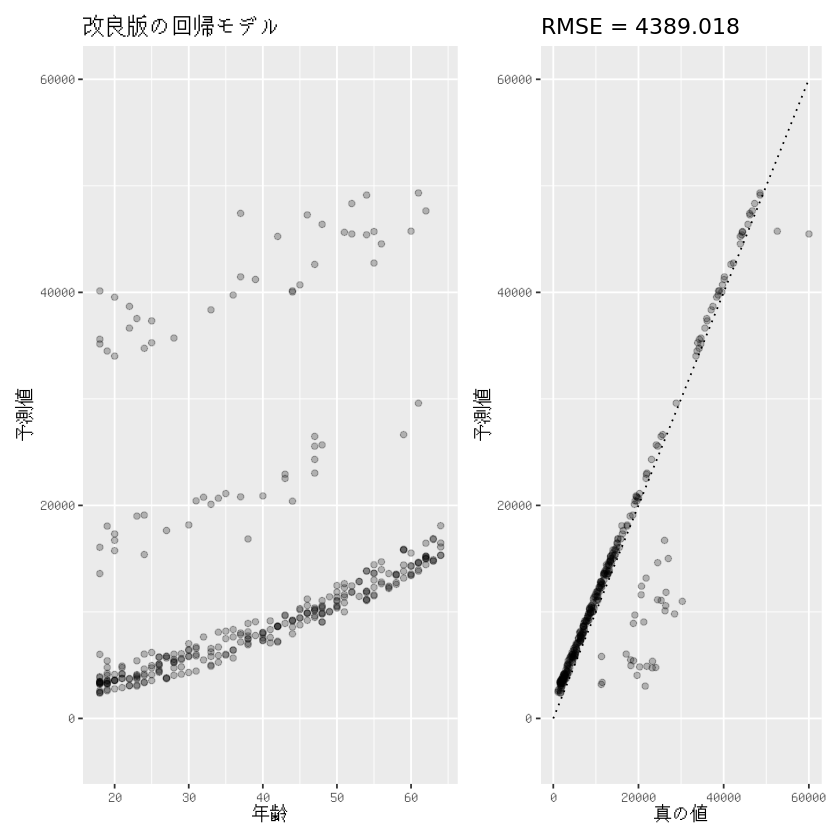

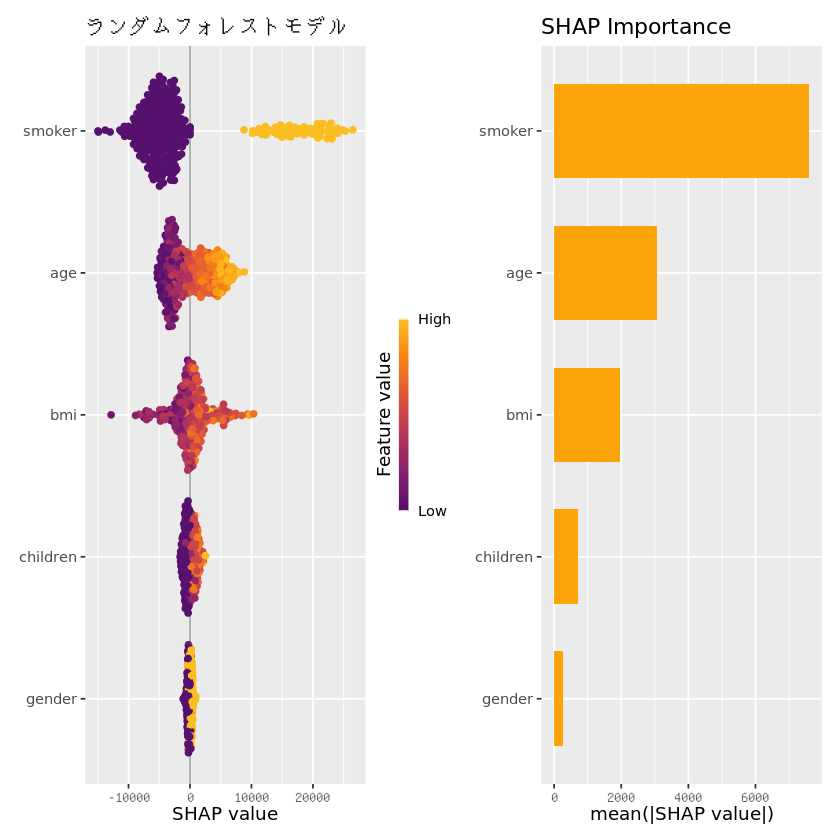

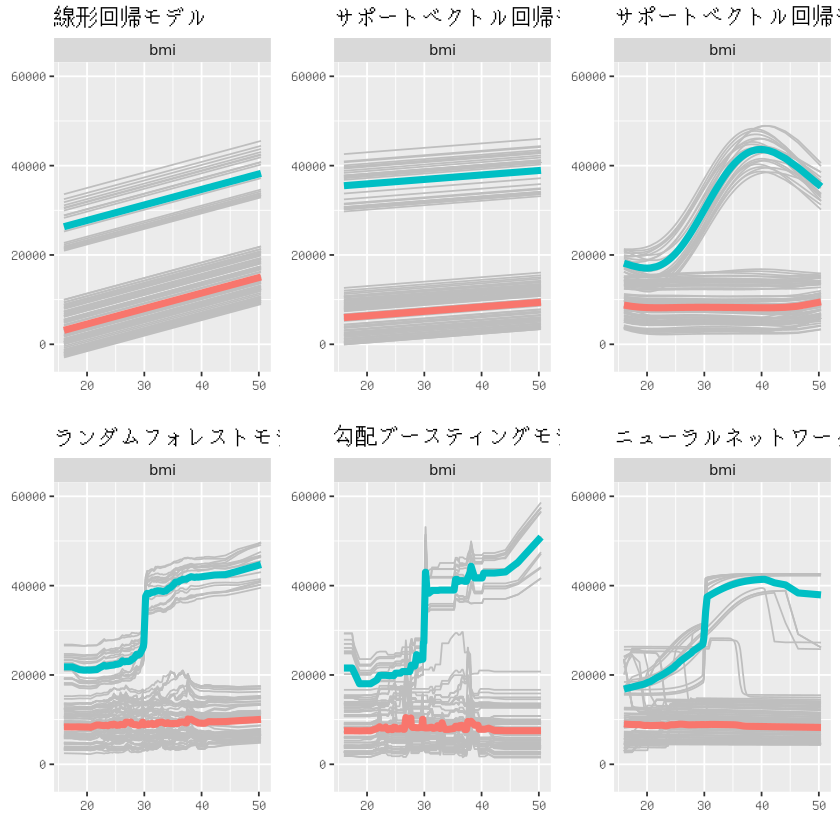

In [2]:
        
            ### ブラックボックスな予測モデルの力を借りてデータを分析してみよう - 実行用Rスクリプト
        
        
            ## 予測モデルを作るのは、実はそれほど難しくない
            
            
            # 必要なパッケージのインストール状況を確認し、見つからない場合はインストールします。
            pkgs = c('tidyverse', 'tidymodels', 'GGally', 'patchwork', 'gridExtra', 'liver',
                     'ranger', 'xgboost', 'kernlab', 'nnet', 'DALEX', 'shapviz', 'fastshap')
            for (pkg in pkgs) {
                if (!require(pkg, quietly=TRUE, character.only=TRUE)) install.packages(pkg)
            }
            
            
            # データを読み込み、変数のうちgenderとsmokerを数値化、regionを削除します。
            library('tidyverse')
            library('liver')
            data(insurance)
            df = insurance %>%
                mutate(gender=as.numeric(gender=='female'),
                       smoker=as.numeric(smoker=='yes')) %>%
                select(-region)
            df %>% str()
            
            
            # データを学習用データと評価用データに分割し、分割後のデータ件数を確認します。
            library('tidymodels')
            set.seed(2023)
            split_data = initial_split(df, prop=3/4)
            train = training(split_data)
            test = testing(split_data)
            cat(nrow(train), nrow(test))
            
            
            # 学習用データの分布と相関係数をまとめて可視化します。
            library('GGally')
            ggpairs(train, lower=list(continuous=wrap(ggally_points, alpha=.1)))
            
            
            # 予測モデルに対して、予測値のプロットと評価を表示する関数を定義します。
            library('patchwork')
            evaluate_model = function(model, new_data){
                aug = augment(model, new_data=new_data)
                loss = rmse(aug, charge, .pred)$.estimate %>% round(3)
                p = ggplot() + ylim(-3000, 60000) + ylab('予測値')
                p1 = p + geom_point(aes(x=age, y=.pred), data=aug, alpha=.25) +
                    labs(title=model$title, x='年齢')
                p2 = p + geom_point(aes(x=charge, y=.pred), data=aug, alpha=.25) +
                    geom_line(aes(x=c(0, 60000), y=c(0, 60000)), lty=3) +
                    labs(title=paste('RMSE =', loss), x='真の値')
                p1 + p2 + plot_layout(widths=c(4, 3))
                }
            
            
            # 線形回帰モデルを作成します。作成した予測モデルはリストに格納します。
            models = list()
            models[['lm']] = linear_reg() %>% fit(charge~., train)
            models[['lm']]$title = '線形回帰モデル'
            evaluate_model(models[['lm']], test)
            
            
            # サポートベクトル回帰モデル（線形カーネル）を作成します。
            models[['svl']] = svm_linear() %>% set_engine('kernlab') %>%
                set_mode('regression') %>% fit(charge~., train)
            models[['svl']]$title = 'サポートベクトル回帰モデル - 線形カーネル'
            evaluate_model(models[['svl']], test)
            
            
            # サポートベクトル回帰モデル（RBFカーネル）を作成します。
            models[['svr']] = svm_rbf() %>%
                set_mode('regression') %>% fit(charge~., train)
            models[['svr']]$title = 'サポートベクトル回帰モデル - RBFカーネル'
            evaluate_model(models[['svr']], test)
            
            
            # ランダムフォレストモデルを作成します。
            models[['rf']] = rand_forest() %>%
                set_mode('regression') %>% fit(charge~., train)
            models[['rf']]$title = 'ランダムフォレストモデル'
            evaluate_model(models[['rf']], test)
            
            
            # 勾配ブースティングモデル（XGBoost）を作成します。
            models[['gbm']] = boost_tree() %>%
                set_mode('regression') %>% fit(charge~., train)
            models[['gbm']]$title = '勾配ブースティングモデル - XGBoost'
            evaluate_model(models[['gbm']], test)
            
            
            # ニューラルネットワークモデルを作成します。
            models[['nn']] = mlp(penalty=10, epochs=600) %>%
                set_mode('regression') %>% fit(charge~., train)
            models[['nn']]$title = 'ニューラルネットワークモデル'
            evaluate_model(models[['nn']], test)
            
            
            ## 作成した予測モデルは、データの分析にも役立つ
            
            
            # DALEXパッケージで予測モデルを解釈するための前準備を行います。
            library('shapviz')
            library('DALEX')
            explainers = list()
            for (name in names(models)){
                explainers[[name]] = DALEX::explain(model=models[[name]],
                                                    data=select(test, -charge),
                                                    y=test$charge)
                explainers[[name]]$title = models[[name]]$title
            }
            
            
            # PFIプロットを作図します。
            pfi = explainers[['rf']] %>% model_parts()
            plot(pfi) + labs(title=explainers[['rf']]$title, subtitle=NULL) +
                ylab('変数の値を並び替えたあとのRMSE') + theme_gray() +
                theme(legend.position='none', strip.text=element_blank())
            
            
            # ICEプロットを作図します。
            ice = explainers[['rf']] %>% predict_profile(test)
            plot(ice, variables=c('age', 'bmi')) +
                labs(title=explainers[['rf']]$title, subtitle=NULL, y='予測値') +
                ylim(0, 53000) + theme_gray()
            
            
            # PDP（Partial Dependence Plot）を作図します。
            pdp = explainers[['rf']] %>% model_profile()
            plot(pdp, variables=c('age', 'bmi'), geom='profiles') +
                labs(title=explainers[['rf']]$title, subtitle=NULL, y='予測値') +
                ylim(0, 53000) + theme_gray() + theme(legend.position='none')
            
            
            # 喫煙の有無でグループ化したPDP（Grouped PDP）を作図します。
            gpd = explainers[['rf']] %>% model_profile(groups='smoker')
            plot(gpd, variables=c('age', 'bmi'), geom='profiles') +
                labs(title=explainers[['rf']]$title, subtitle=NULL, y='予測値') +
                ylim(0, 53000) + theme_gray() + theme(legend.position='none')
            
            
            # 1番目のインスタンスに関するSHAPウォーターフォール図を作図します。
            shap1 = explainers[['rf']] %>% predict_parts(test[1,], type='shap')
            sv_waterfall(shapviz(shap1)) +
                ggtitle(paste(explainers[['rf']]$title, '- 1番目のインスタンス')) +
                xlab('予測値') + theme_gray()
            
            
            # 10番目のインスタンスに関するSHAPウォーターフォール図を作図します。
            shap2 = explainers[['rf']] %>% predict_parts(test[10,], type='shap')
            sv_waterfall(shapviz(shap2)) +
                ggtitle(paste(explainers[['rf']]$title, '- 10番目のインスタンス')) +
                xlab('予測値') + theme_gray()
            
            
            # ブラックボックスモデルの解釈を回帰式に反映させた線形回帰モデルを作成します。
            models[['tr']] = linear_reg() %>%
                fit(charge~. + I(age^2) + smoker:bmi + I(smoker*as.numeric(bmi>30)), train)
            models[['tr']]$title = '改良版の回帰モデル'
            evaluate_model(models[['tr']], test)
            
            
            ## Appendix
            
            
            # 評価用データ全体に対するSHAP Importanceを計算します。
            library('fastshap')
            pred_parsnip = function(object, newdata){
                predict(object, new_data=newdata)$.pred
                }
            shap = fastshap::explain(object=models[['rf']],
                                     X=select(train, -charge),
                                     newdata=select(test, -charge),
                                     pred_wrapper=pred_parsnip,
                                     nsim=20)
            sv = shapviz(shap, X=test)
            p = sv_importance(sv, 'bee') + ggtitle(models[['rf']]$title)
            q = sv_importance(sv) + ggtitle('SHAP Importance')
            p + q
            
            
            # BMIに関する各予測モデルのGrouped PDPをまとめて作図します。
            library('gridExtra')
            plots = list()
            for (name in names(explainers)){
                gpd = explainers[[name]] %>% model_profile(groups='smoker')
                p = plot(gpd, variables=c('bmi'), geom='profiles') +
                    labs(title=explainers[[name]]$title, subtitle=NULL, y=NULL) +
                    ylim(-3000, 60000)
                plots[[name]] = p + theme_gray() + theme(legend.position='none')
            }
            grid.arrange(grobs=plots, ncol=3)
            
        
    


Analyzing Model: 線形回帰モデル 
UR (Uninterpreted Rate): 0 

MID Importance based on 335 Observations

Measure: Root Mean Square Contribution

Importance:
              term importance order
1           smoker 9.4502e+03     1
2              age 3.7371e+03     1
3              bmi 2.1817e+03     1
4         children 4.8304e+02     1
5           gender 2.2993e+02     1
6       bmi:smoker 8.1702e-02     2
7     bmi:children 4.4477e-02     2
8          age:bmi 4.3848e-02     2
9       age:gender 3.1498e-02     2
10      bmi:gender 2.5749e-02     2
11      age:smoker 2.5069e-02     2
12   smoker:gender 2.0115e-02     2
13    age:children 2.0073e-02     2
14 children:smoker 1.8959e-02     2
15 children:gender 1.4497e-02     2

Analyzing Model: サポートベクトル回帰モデル - 線形カーネル 
UR (Uninterpreted Rate): 0 


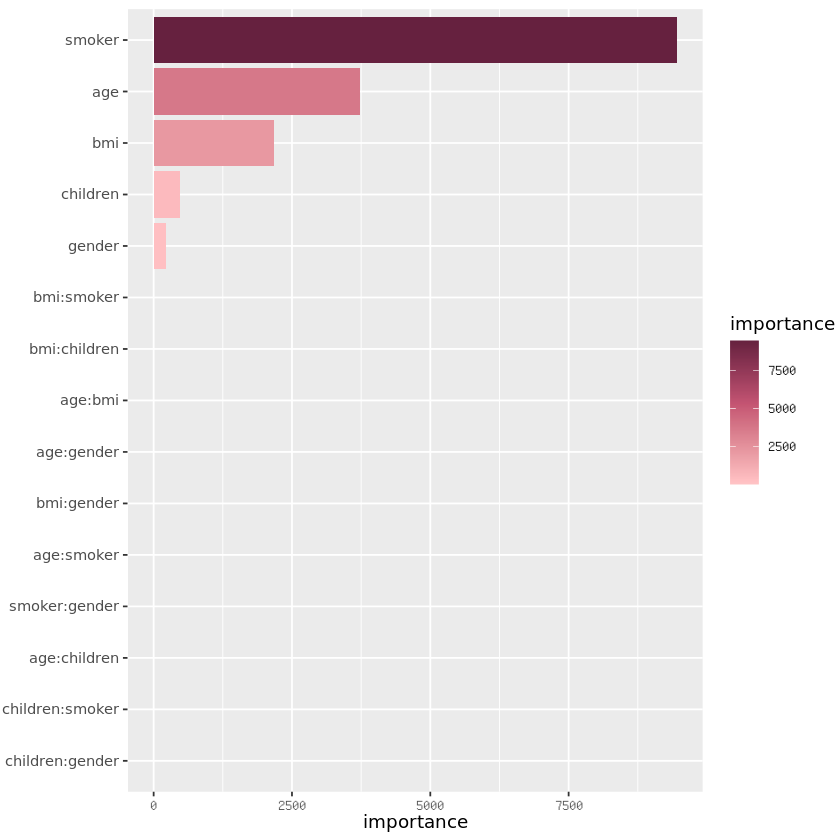


MID Importance based on 335 Observations

Measure: Root Mean Square Contribution

Importance:
              term importance order
1           smoker 1.1950e+04     1
2              age 3.7919e+03     1
3              bmi 6.2734e+02     1
4         children 4.9307e+02     1
5           gender 2.2173e+02     1
6       bmi:smoker 2.7542e-02     2
7          age:bmi 2.2158e-02     2
8     bmi:children 2.1206e-02     2
9  children:smoker 1.5810e-02     2
10    age:children 1.3390e-02     2
11      age:smoker 1.3234e-02     2
12      age:gender 1.0458e-02     2
13 children:gender 9.1364e-03     2
14      bmi:gender 8.7748e-03     2
15   smoker:gender 7.9731e-03     2

Analyzing Model: サポートベクトル回帰モデル - RBFカーネル 
UR (Uninterpreted Rate): 0.003295 


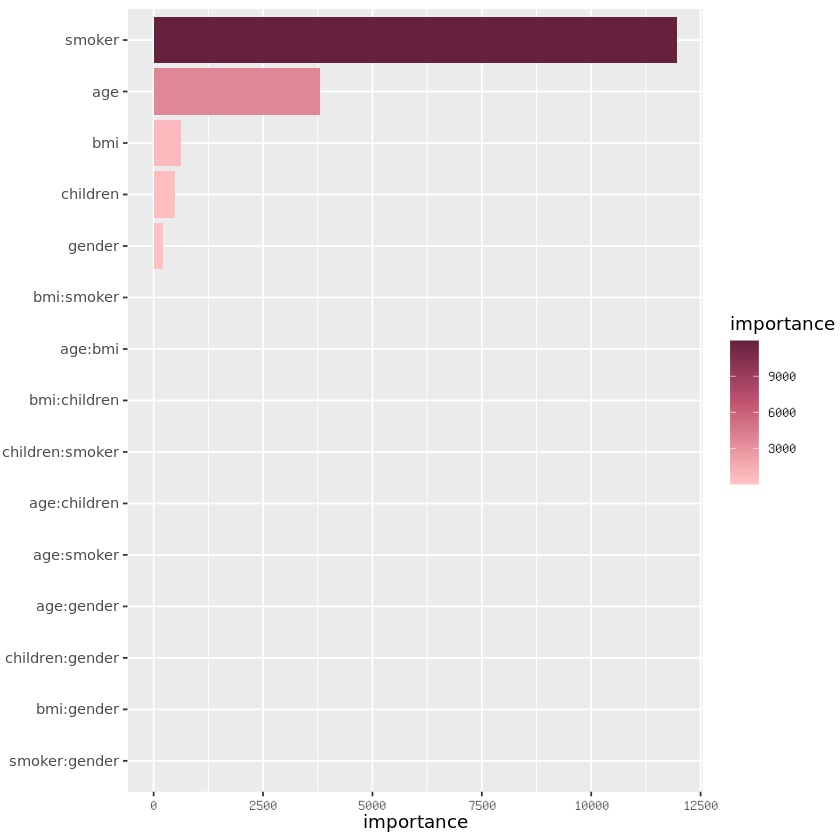


MID Importance based on 335 Observations

Measure: Root Mean Square Contribution

Importance:
              term importance order
1           smoker   9214.723     1
2              age   3922.003     1
3       bmi:smoker   3441.712     2
4              bmi   1685.606     1
5         children    603.687     1
6  children:smoker    329.760     2
7           gender    249.676     1
8          age:bmi    209.864     2
9       age:smoker    137.260     2
10      bmi:gender    121.711     2
11    bmi:children    116.261     2
12    age:children    109.228     2
13 children:gender     98.585     2
14      age:gender     71.604     2
15   smoker:gender     32.662     2

Analyzing Model: ランダムフォレストモデル 
UR (Uninterpreted Rate): 0.009258 


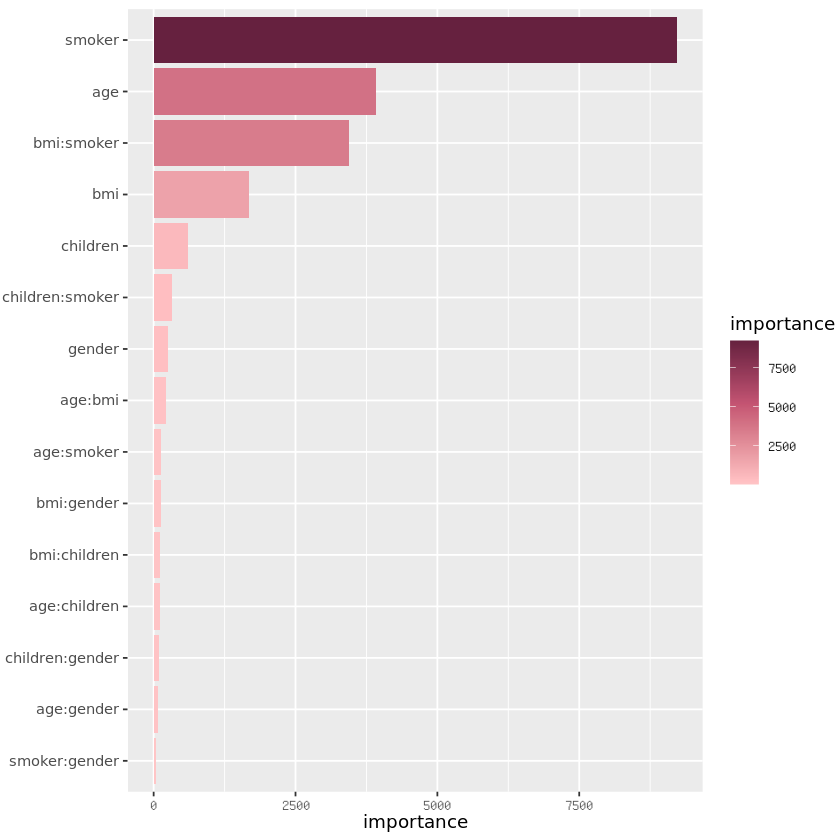


MID Importance based on 335 Observations

Measure: Root Mean Square Contribution

Importance:
              term importance order
1           smoker    9374.82     1
2              age    3442.53     1
3       bmi:smoker    3172.67     2
4              bmi    1754.66     1
5         children     700.94     1
6     age:children     490.03     2
7  children:smoker     447.93     2
8       age:smoker     242.30     2
9           gender     237.86     1
10 children:gender     230.33     2
11    bmi:children     226.29     2
12         age:bmi     224.98     2
13      age:gender     182.54     2
14      bmi:gender     174.37     2
15   smoker:gender     107.32     2

Analyzing Model: 勾配ブースティングモデル - XGBoost 
Error in model gbm : [14:56:25] src/predictor/utils.h:20: Check failed: n_features_data == n_features_model (6 vs. 5) : Number of columns in data must equal to the trained model.
Stack trace:
  [bt] (0) /home/kazu/R/x86_64-pc-linux-gnu-library/4.5/xgboost/libs/xgboost.so(+0x779a9) [0x7f

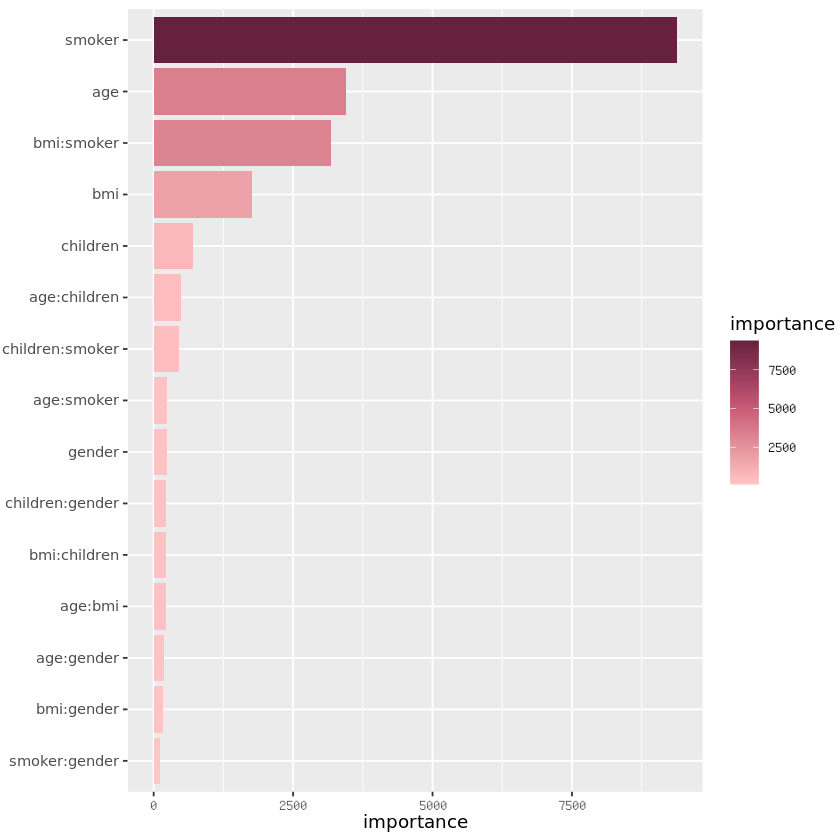


MID Importance based on 335 Observations

Measure: Root Mean Square Contribution

Importance:
              term importance order
1           smoker   9110.924     1
2              age   3739.444     1
3       bmi:smoker   3198.172     2
4              bmi   1752.092     1
5       age:smoker    689.213     2
6         children    687.100     1
7     age:children    668.079     2
8       age:gender    535.207     2
9     bmi:children    343.540     2
10         age:bmi    340.259     2
11 children:gender    329.449     2
12 children:smoker    255.738     2
13   smoker:gender    118.836     2
14      bmi:gender     86.632     2
15          gender     84.162     1

Analyzing Model: 改良版の回帰モデル 
UR (Uninterpreted Rate): 0.007939 


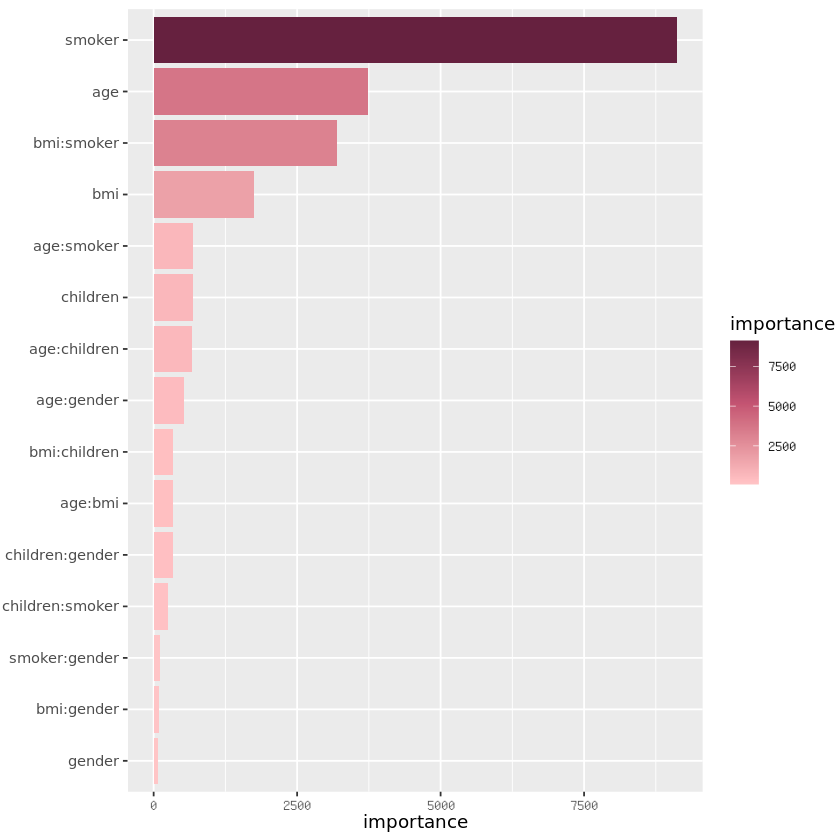


MID Importance based on 335 Observations

Measure: Root Mean Square Contribution

Importance:
              term importance order
1           smoker   9720.358     1
2              age   3873.826     1
3       bmi:smoker   3788.044     2
4              bmi   1970.291     1
5         children    718.628     1
6           gender    425.862     1
7     age:children    307.474     2
8     bmi:children    188.271     2
9  children:smoker    147.699     2
10      age:gender    146.447     2
11      bmi:gender    108.230     2
12         age:bmi    106.648     2
13      age:smoker     89.438     2
14 children:gender     56.502     2
15   smoker:gender     54.661     2

### UR Summary ###
         lm         svl         svr          rf          nn          tr 
0.000000000 0.000000000 0.003294902 0.009257916 0.013647903 0.007938543 


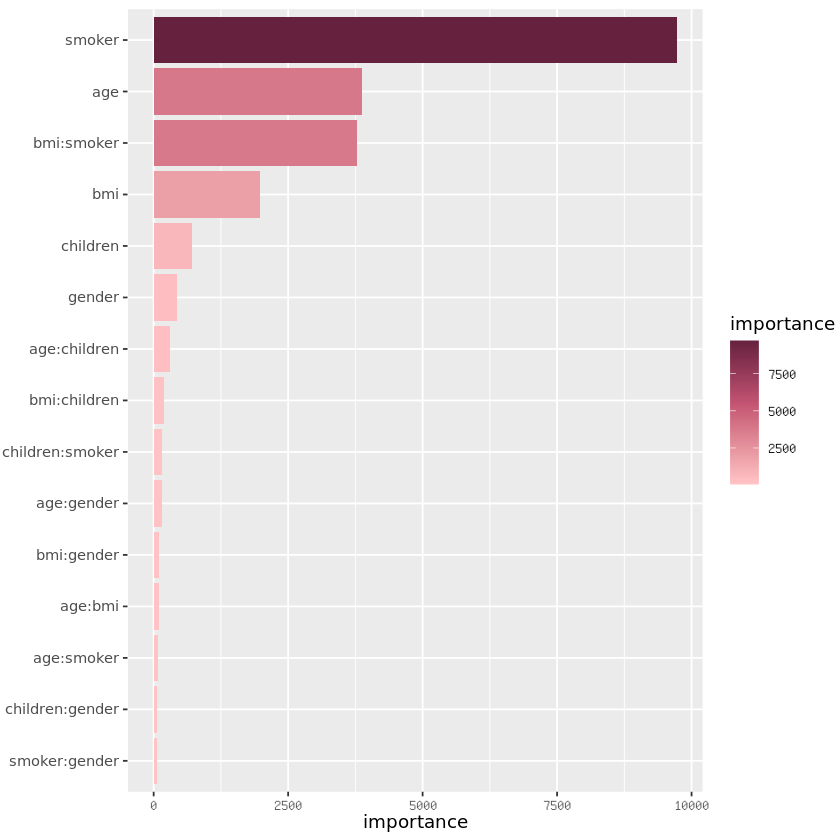

In [10]:
library(midr)

ur_results <- list()
cols_to_use <- c("age", "bmi", "children", "smoker", "gender")

for (name in names(models)) {
  if (is.null(models[[name]])) next
  cat("\n============================================\n")
  cat("Analyzing Model:", models[[name]]$title, "\n")
  
  tryCatch({
    # 1. データの抽出（データフレーム型を維持し、列順を固定）
    input_data <- as.data.frame(test[, cols_to_use])
    
    # 2. 予測値の計算
    y_hat_val <- predict(models[[name]], new_data = input_data)$.pred
    
    # 3. midr解析用データの準備
    df_mid_eval <- input_data
    df_mid_eval$y <- y_hat_val
    
    # 4. 関数分解の実行
    # XGBoost等のエラーを避けるため、model引数には fit(models[[name]]) を渡します
    res <- midr::interpret(
      y ~ (.)^2, 
      data = df_mid_eval, 
      model = models[[name]]$fit
    )
    
    # 5. UR (ratio) の記録
    ur_results[[name]] <- res$ratio
    cat("UR (Uninterpreted Rate):", round(res$ratio, 6), "\n")
    
    # 6. 重要度の抽出とソート（ご指摘の箇所を修正）
    imp_df <- mid.importance(res, measure = 2)
    p <- ggmid(imp_df, theme = "Burg_r")
    print(p)
    print(imp_df)

    # 列名 'importance' を使って降順ソート
    #top_terms <- imp_df[order(imp_df$importance, decreasing = TRUE), ]
    
    #cat("\nTop 3 Important Terms:\n")
    # 不要な行（(Intercept)など）を除いて上位3つを表示
    #print(head(top_terms, 3))
    
  }, error = function(e) {
    cat("Error in model", name, ":", e$message, "\n")
  })
}

cat("\n### UR Summary ###\n")
print(unlist(ur_results))

In [11]:
# URの感度分析（lambdaの影響を確認）
lambda_list <- c(0, 0.01, 0.1)
results_lambda <- data.frame()

for (l in lambda_list) {
  for (name in c("rf", "nn", "tr")) {
    if (is.null(models[[name]])) next
    
    # データの準備
    input_data <- as.data.frame(test[, c("age", "bmi", "children", "smoker", "gender")])
    y_hat <- predict(models[[name]], new_data = input_data)$.pred
    df_mid <- input_data %>% mutate(y = y_hat)
    
    # lambdaを指定して解析
    res <- midr::interpret(y ~ (.)^2, data = df_mid, model = models[[name]]$fit, lambda = l)
    
    results_lambda <- rbind(results_lambda, data.frame(
      model = name,
      lambda = l,
      UR = res$ratio
    ))
  }
}

print(results_lambda)

not strictly centered: max absolute average effect = 3.01677e-06

not strictly centered: max absolute average effect = 2.94685e-06

not strictly centered: max absolute average effect = 3.1233e-06

not strictly centered: max absolute average effect = 1.87907e-05

not strictly centered: max absolute average effect = 1.83702e-05

not strictly centered: max absolute average effect = 1.93897e-05



  model lambda          UR
1    rf   0.00 0.009257916
2    nn   0.00 0.013647903
3    tr   0.00 0.007938543
4    rf   0.01 0.012507496
5    nn   0.01 0.015594606
6    tr   0.01 0.012062398
7    rf   0.10 0.141608468
8    nn   0.10 0.142698072
9    tr   0.10 0.139415959


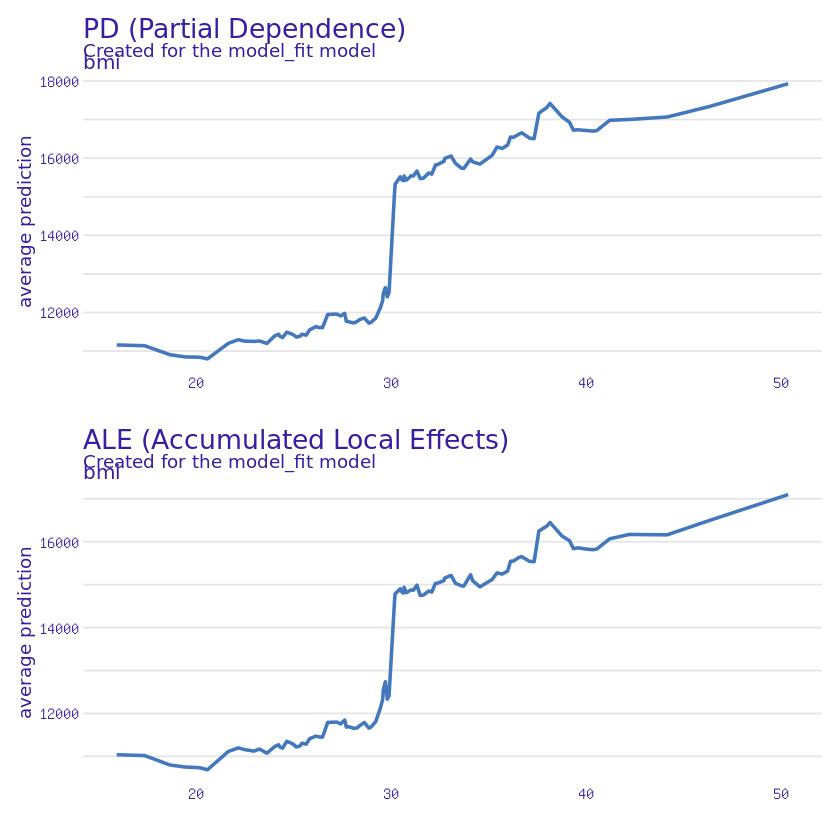

In [12]:
library(DALEX)
library(patchwork)

# 比較したい変数（例：bmi）
var_name <- "bmi"

# 1. PD (Partial Dependence) の計算
pdp <- model_profile(explainers$rf, variables = var_name, type = "partial")

# 2. ALE (Accumulated Local Effects) の計算
ale <- model_profile(explainers$rf, variables = var_name, type = "accumulated")

# 3. グラフで比較
p1 <- plot(pdp) + ggtitle("PD (Partial Dependence)")
p2 <- plot(ale) + ggtitle("ALE (Accumulated Local Effects)")

p1 / p2